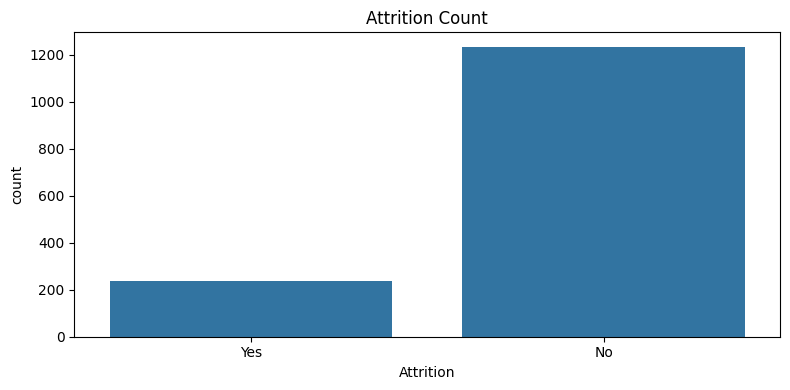

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

data_path = Path("/content/hr_employee_attrition.csv")
df = pd.read_csv(data_path)

df = df.drop_duplicates()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

if "EmployeeNumber" in df.columns:
    df = df.drop(columns=["EmployeeNumber"])

if "Attrition" in df.columns:
    df["Attrition_Flag"] = df["Attrition"].map({"Yes": 1, "No": 0})

if "OverTime" in df.columns:
    df["OverTime_Flag"] = df["OverTime"].map({"Yes": 1, "No": 0})

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in ["Attrition"]]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

output_dir = Path("data")
output_dir.mkdir(parents=True, exist_ok=True)
cleaned_path = output_dir / "hr_employee_attrition_cleaned.csv"
encoded_path = output_dir / "hr_employee_attrition_encoded.csv"

df.to_csv(cleaned_path, index=False)
df_encoded.to_csv(encoded_path, index=False)


Path("figures").mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 4))
sns.countplot(x="Attrition", data=df)
plt.title("Attrition Count")
plt.tight_layout()
plt.savefig("figures/attrition_count.png")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
Path("figures").mkdir(exist_ok=True, parents=True)
plt.savefig("figures/correlation_heatmap.png")
plt.close()

dept_col = "Department"
if dept_col in df.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=dept_col, hue="Attrition", data=df)
    plt.xticks(rotation=30, ha="right")
    plt.title("Attrition by Department")
    plt.tight_layout()
    plt.savefig("figures/attrition_by_department.png")
    plt.close()

role_col = "JobRole"
if role_col in df.columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=role_col, hue="Attrition", data=df)
    plt.xticks(rotation=45, ha="right")
    plt.title("Attrition by Job Role")
    plt.tight_layout()
    plt.savefig("figures/attrition_by_jobrole.png")
    plt.close()
